### Bestseller Prediction & Recommendation System

In [8]:
import pandas as pd
df = pd.read_csv("amozon.csv")
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [10]:
df.tail()

,Name,Author,User Rating,Reviews,Price,Year,Genre
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction
549,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2019,Non Fiction


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [14]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [16]:
df.shape

(550, 7)

In [18]:
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

In [20]:
df.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

### Convert Genre to Numeric


In [23]:
df["Genre"] = df["Genre"].map({"Fiction" : 0, "Non Fiction" : 1})
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,1
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,0
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,1
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,0
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,1


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

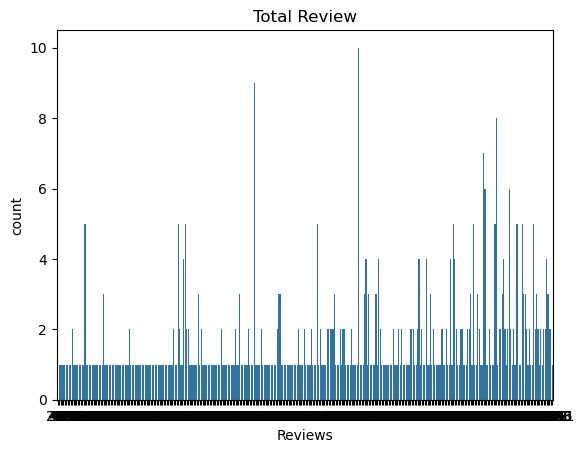

In [26]:
sns.countplot(x="Reviews" , data=df)
plt.title("Total Review")
plt.show()

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

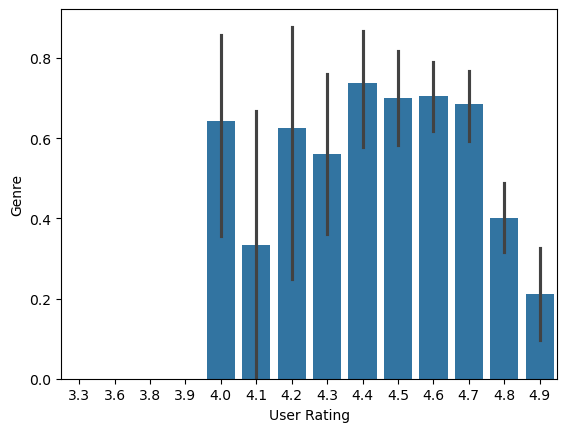

In [56]:
sns.barplot(x="User Rating", y="Genre", data = df)
plt.title


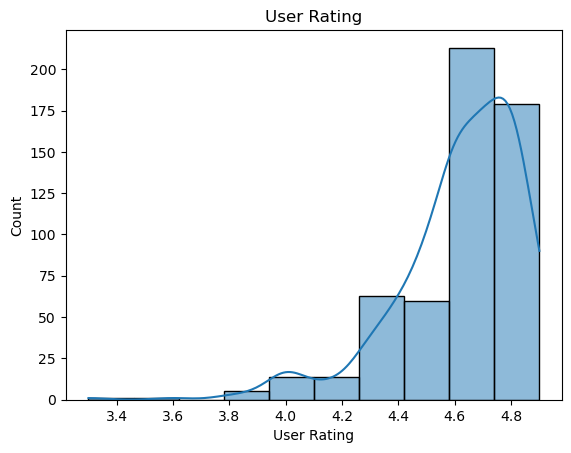

In [58]:
sns.histplot(df["User Rating"], bins=10, kde= True)
plt.title("User Rating")
plt.show()

### Top Authors

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

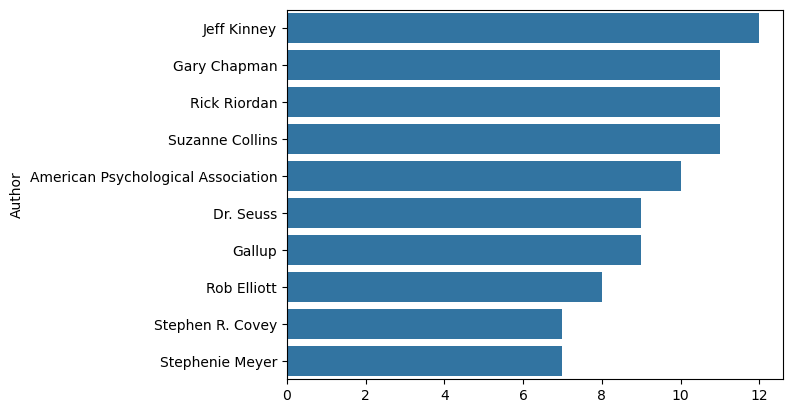

In [30]:
top_authors = df["Author"].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title

###  Price vs Rating

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

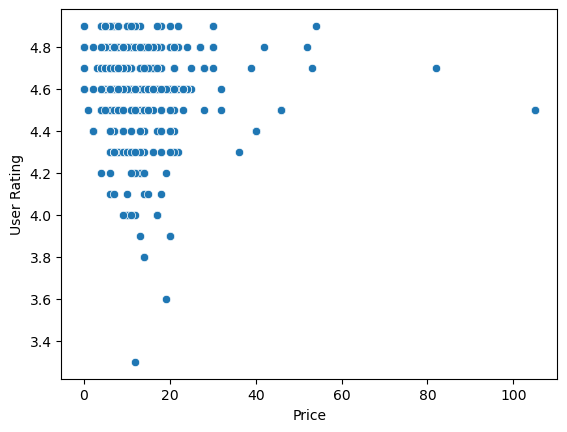

In [40]:
sns.scatterplot(x="Price", y="User Rating", data=df)
plt.title

### Reviews vs Rating

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

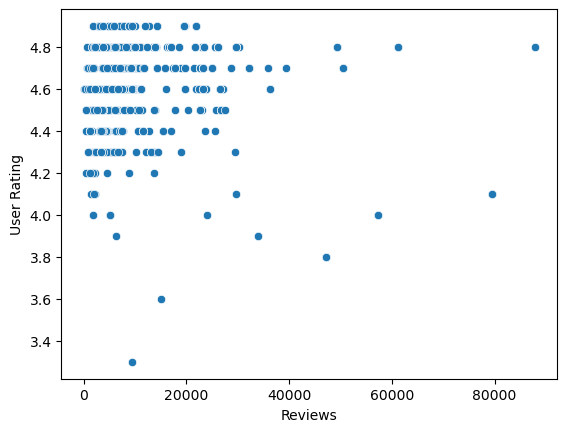

In [45]:
sns.scatterplot(x="Reviews", y="User Rating", data=df)
plt.title

### Average Rating by Genre

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

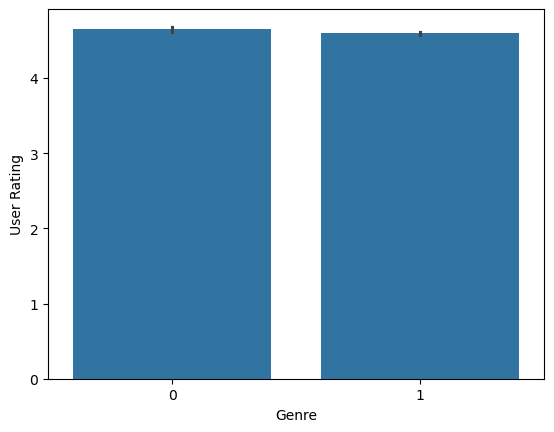

In [48]:
sns.barplot(x="Genre", y="User Rating", data=df)
plt.title

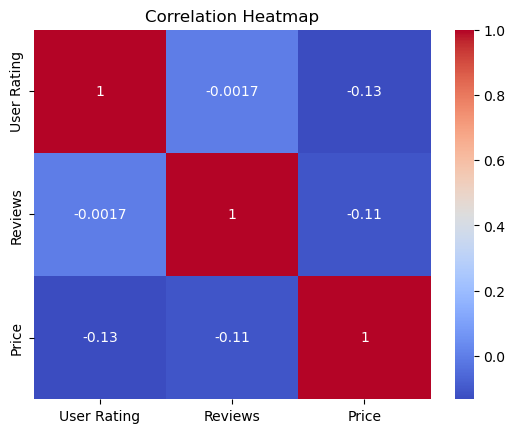

In [64]:
corr =df[["User Rating", "Reviews", "Price"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [70]:
# Create taarget column
df["Bestseller"]=(df["User Rating"]>4.5).astype(int)


In [74]:
#Features
x=df[["Reviews", "Price", "Genre"]]
y=df["Bestseller"]

### Train Model

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4)
model = RandomForestClassifier()
model.fit(x_train, y_train)
print("Accuracy:", model.score(x_test, y_test))

Accuracy: 0.7818181818181819


### Feature Importance 

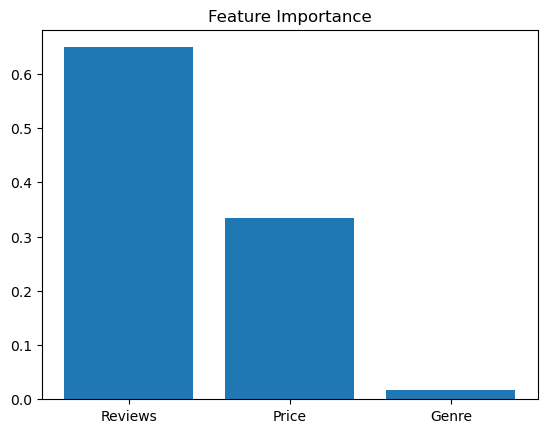

In [86]:
import matplotlib.pyplot as plt
importance = model.feature_importances_
plt.bar(["Reviews", "Price", "Genre"], importance)
plt.title("Feature Importance")
plt.show()

### Recommendation System

In [93]:
from sklearn.metrics.pairwise import cosine_similarity
#Select features
features = df[["User Rating", "Reviews", "Price"]]

#Similarity Matrix
similarity = cosine_similarity(features)

#Recommend function
def recommend(index):
    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    for i in scores[1:6]:
        print(df.iloc[i[0]]["Name"])

#Example
recommend(0)

Milk and Honey
Milk and Honey
Milk and Honey
Fire and Fury: Inside the Trump White House
Jesus Calling: Enjoying Peace in His Presence (with Scripture References)


In [95]:
import pickle
#Save the model
with open("bestseller_model.pkl", "wb") as file:
    pickle.dump(model, file)